In [21]:
!pip install scikit-learn matplotlib graphviz
!apt-get install graphviz -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [22]:
import kagglehub
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")

Using Colab cache for faster access to the 'breast-cancer-dataset' dataset.


In [23]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import graphviz

In [24]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# 1. CART
cart = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
cart.fit(X_train, y_train)

# 2. Entropy Tree
entropy_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
entropy_tree.fit(X_train, y_train)

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

# 4. Extra Trees
et = ExtraTreesClassifier(n_estimators=10, random_state=42)
et.fit(X_train, y_train)

# 5. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=10, random_state=42)
gb.fit(X_train, y_train)

# 6. AdaBoost
ada = AdaBoostClassifier(n_estimators=10, random_state=42)
ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=10, random_state=42)

In [26]:
def print_tree(tree, depth=0):
    if not isinstance(tree, dict):
        print("  " * depth + f"Leaf: {tree}")
        return

    print("  " * depth + f"[X{tree['feature']} <= {tree['value']}]")
    print_tree(tree['left'], depth + 1)
    print_tree(tree['right'], depth + 1)

print_tree(id3.tree)

[X7 <= 0.05074]
  [X20 <= 16.77]
    [X10 <= 0.6061]
      [X21 <= 30.04]
        Leaf: 1
        [X20 <= 14.37]
          Leaf: 1
          [X0 <= 13.44]
            [X1 <= 26.86]
              Leaf: 0
              Leaf: 1
            Leaf: 1
      [X4 <= 0.08749]
        Leaf: 1
        Leaf: 0
    [X1 <= 15.7]
      Leaf: 1
      [X17 <= 0.009921]
        Leaf: 0
        Leaf: 1
  [X22 <= 114.3]
    [X21 <= 25.47]
      [X27 <= 0.1571]
        Leaf: 1
        Leaf: 0
      [X12 <= 1.513]
        [X0 <= 13.17]
          Leaf: 0
          Leaf: 1
        Leaf: 0
    Leaf: 0


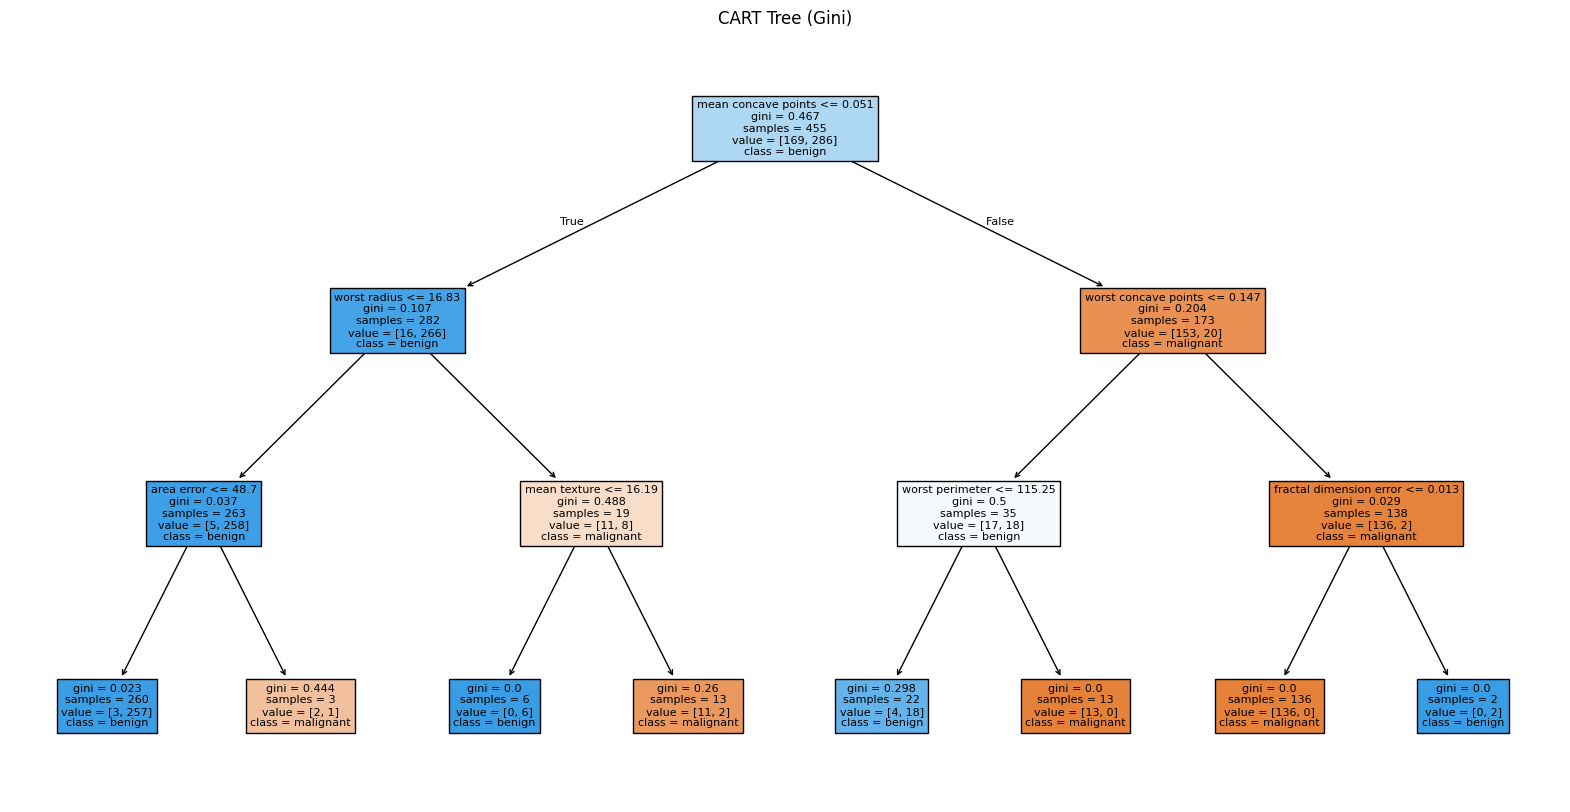

In [27]:
plt.figure(figsize=(20,10))
plot_tree(cart, feature_names=data.feature_names,
          class_names=data.target_names, filled=True)
plt.title("CART Tree (Gini)")
plt.show()

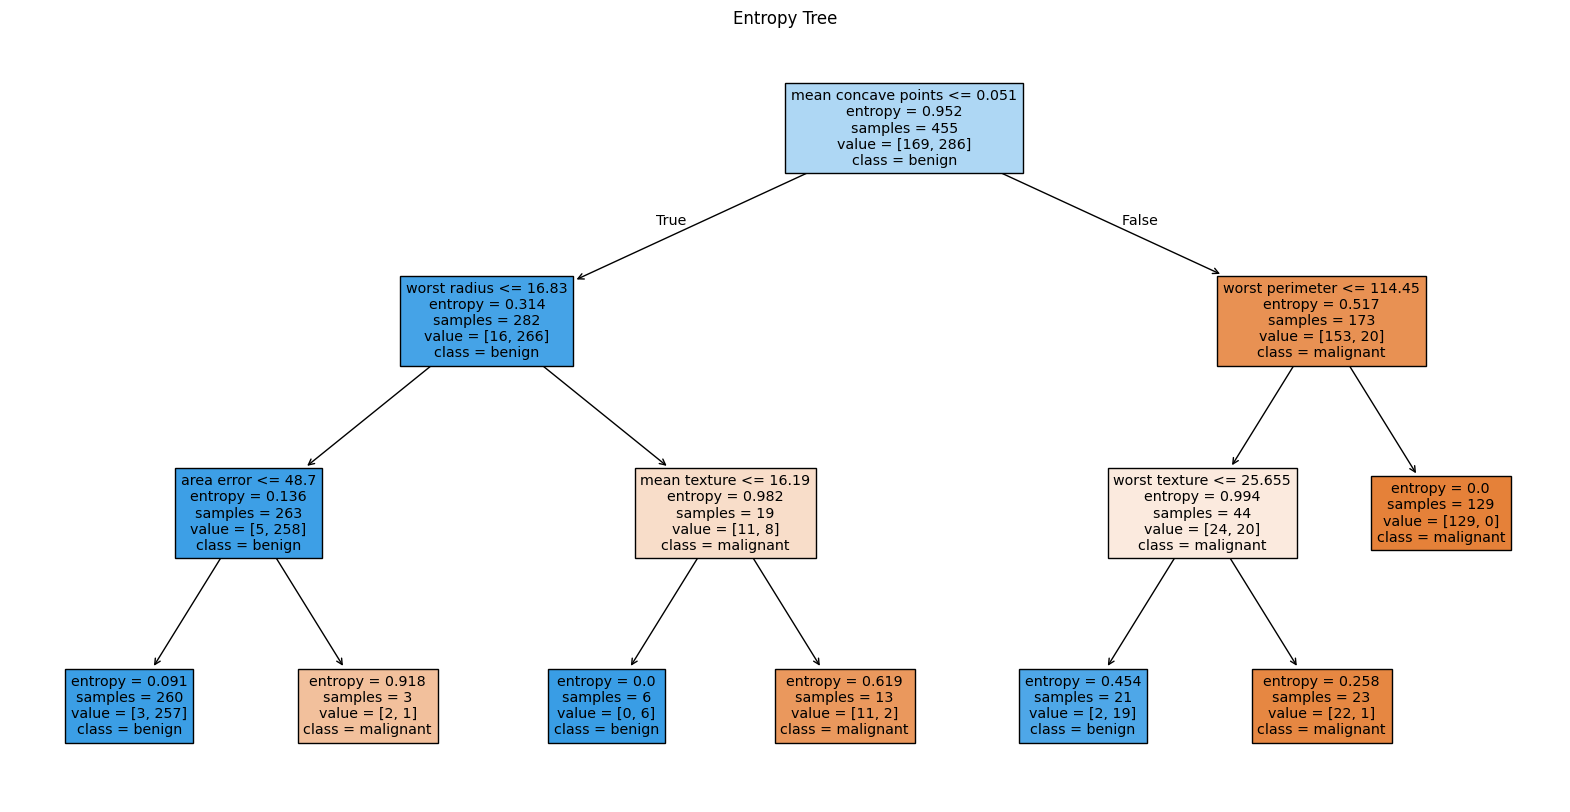

In [28]:
plt.figure(figsize=(20,10))
plot_tree(entropy_tree, feature_names=data.feature_names,
          class_names=data.target_names, filled=True)
plt.title("Entropy Tree")
plt.show()

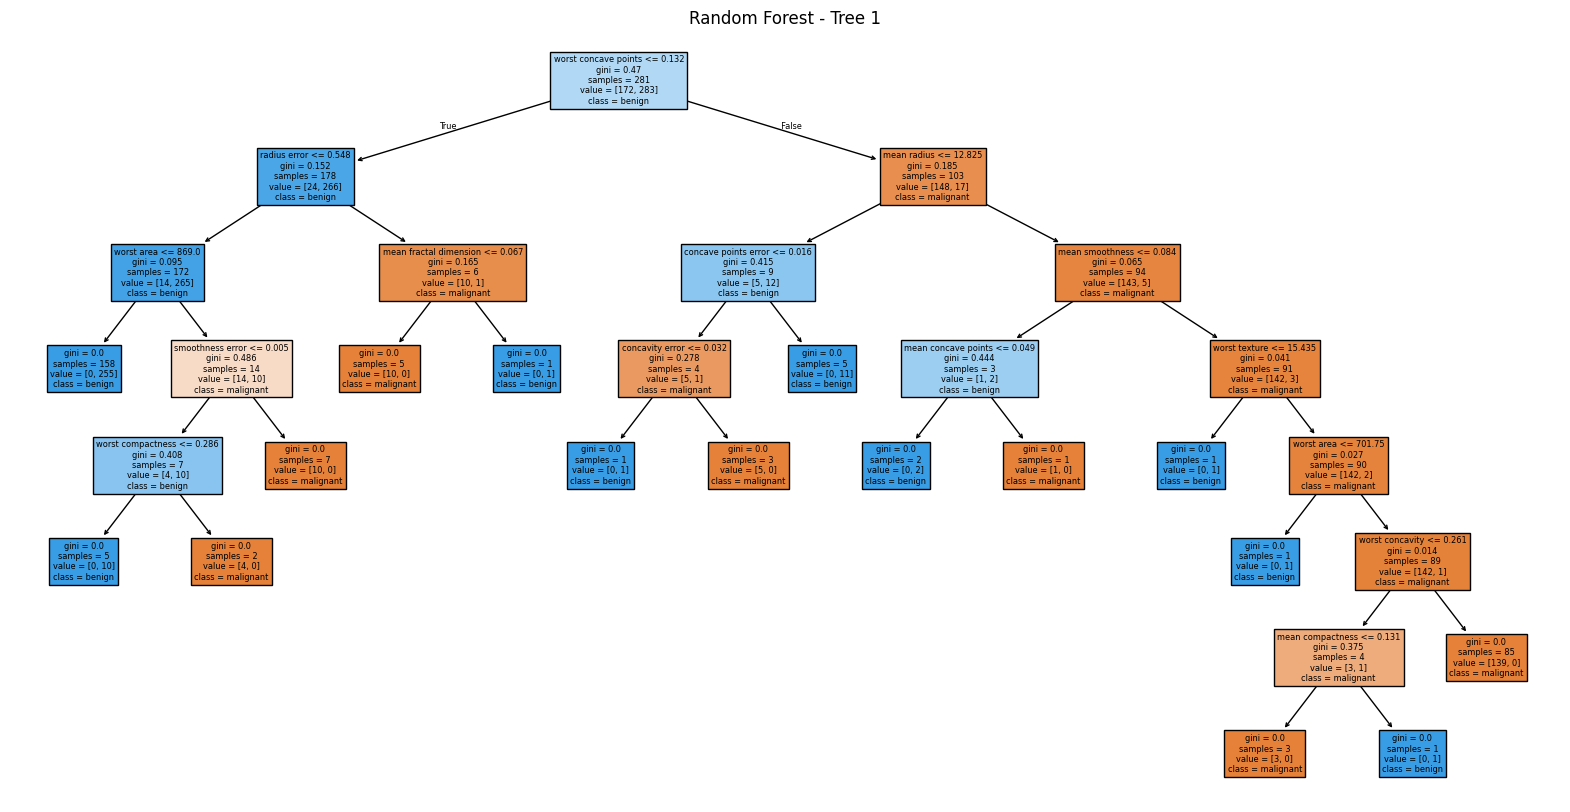

In [30]:
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0],
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True)
plt.title("Random Forest - Tree 1")
plt.show()

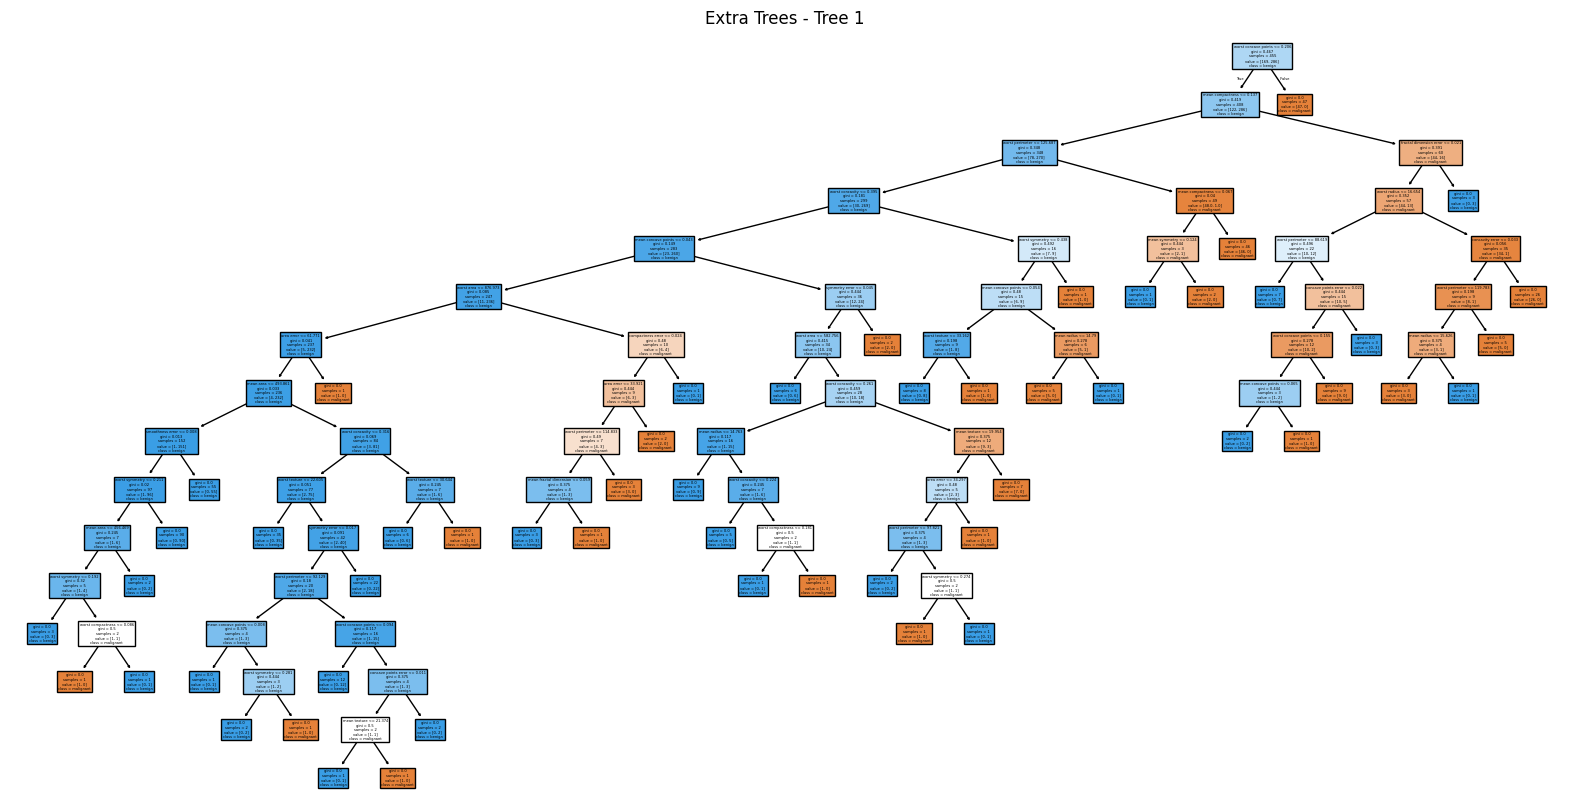

In [32]:
plt.figure(figsize=(20,10))
plot_tree(et.estimators_[0],
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True)
plt.title("Extra Trees - Tree 1")
plt.show()

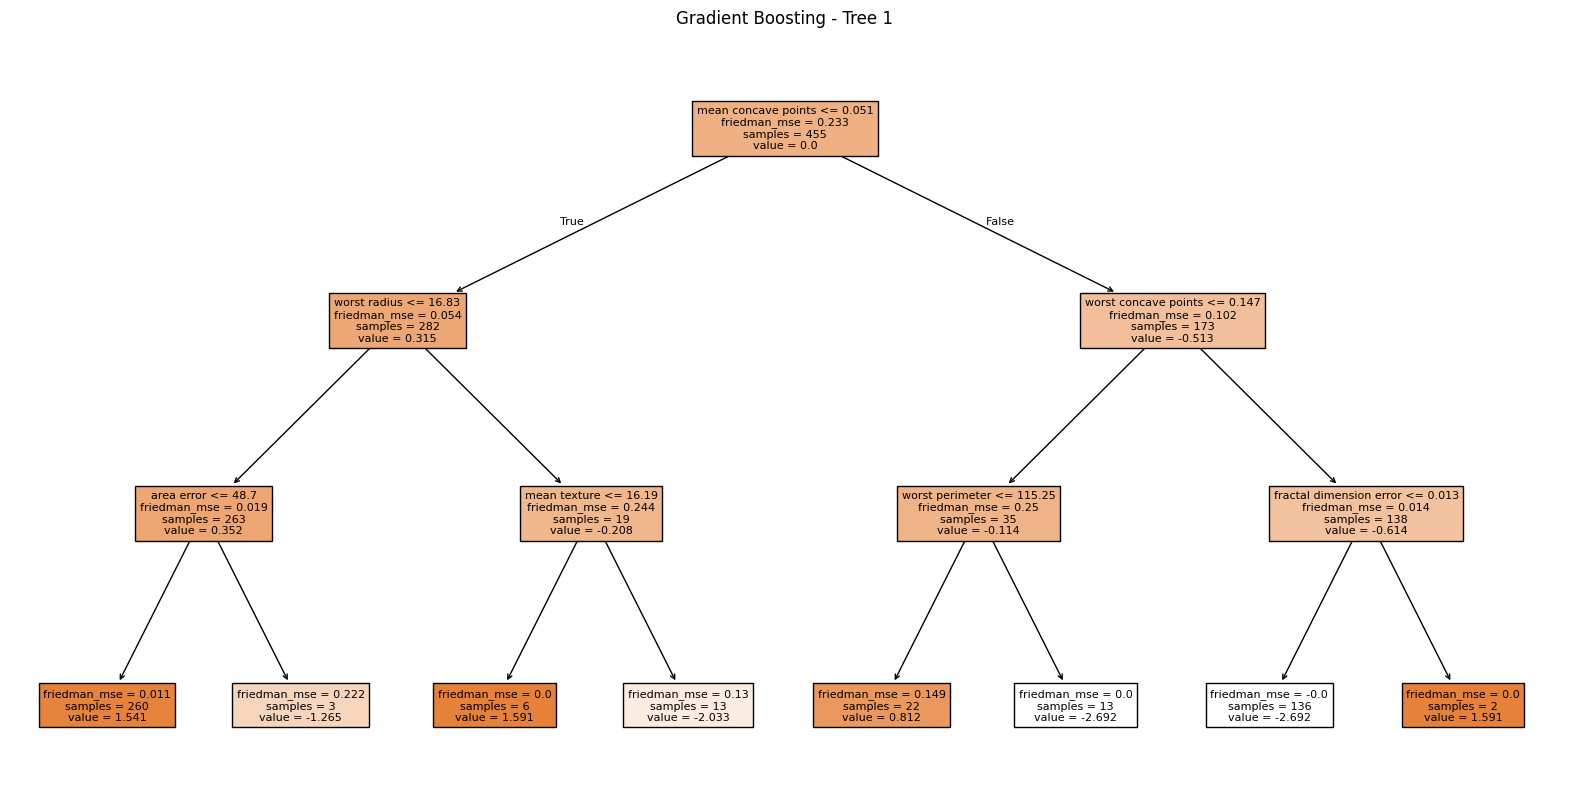

In [33]:
plt.figure(figsize=(20,10))
plot_tree(gb.estimators_[0, 0],
          feature_names=data.feature_names,
          filled=True)
plt.title("Gradient Boosting - Tree 1")
plt.show()

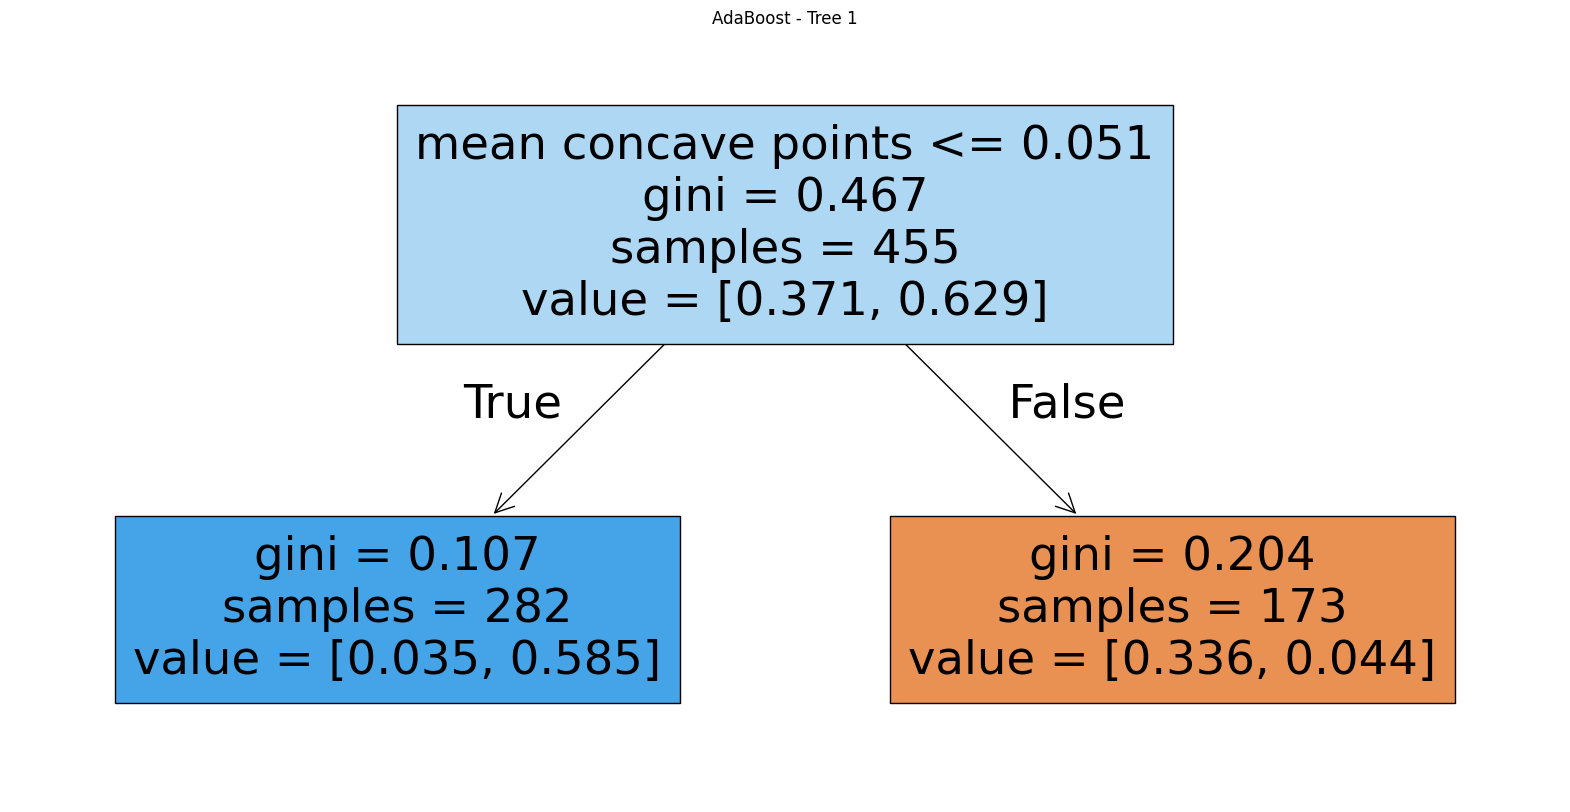

In [34]:
plt.figure(figsize=(20,10))
plot_tree(ada.estimators_[0],
          feature_names=data.feature_names,
          filled=True)
plt.title("AdaBoost - Tree 1")
plt.show()